# PyTorch DL for KDRIFT G1 Alignment

- `decenter+-0.095,tilt+-0.075`
- EDA the training set
- Train using the baseline by the student's work
- `X_f32.npy`: Image Normalization .. Let's find out what is the best "Fixed Max" value for ultimate normalization .. some modification.. not -1 to +1 .. 0 to 1 at absolute full normalization
- `y_f32.npy`: also we need to rescale this .. 

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
#import tensorflow as tf
#from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense, SimpleRNN, Conv2D, MaxPooling2D, Flatten
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
#from tensorflow.keras import backend as K
from tqdm import trange, notebook
#from livelossplot import PlotLossesKeras

import matplotlib.pyplot as plt
import numpy as np

In [2]:
import matplotlib
import seaborn as sns

sns.reset_defaults()                 # seaborn 스타일 제거
matplotlib.rcParams.update(matplotlib.rcParamsDefault)  # matplotlib 완전 초기화

# Basic Settings for matplotlib
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["mathtext.fontset"] = "stix"
#%matplotlib inline
#matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")  # For export
matplotlib.rcParams["lines.linewidth"] = 2.0

## Browsing the working directories

In [3]:
%pwd

'/app/kdrift/decenter+-0.095,tilt+-0.075/pytorch/notebook'

In [4]:
%ls

cnn-align-v6-fixed-maxcap-Xy-rescaled.ipynb
hybrid-align-v3a-tahn-stemch64-ntok64-fixed-maxcap-Xy-rescaled.ipynb
lightning_logs/
no-y-rescaled/
vit-align-v1c-ntok64-fixed-maxcap-Xy-rescaled.ipynb


In [5]:
data_path = '/app/kdrift/decenter+-0.095,tilt+-0.075/pytorch/data/'

In [6]:
!ls {data_path}

X_f32.npy  y_f32.npy


## Explore the training set

In [7]:
%%time
X = np.load(data_path+'X_f32.npy')
y = np.load(data_path+'y_f32.npy')

CPU times: user 586 µs, sys: 211 ms, total: 211 ms
Wall time: 210 ms


In [8]:
len(y),len(X)

(20000, 20000)

In [9]:
def np_array_info(a):
    print(f"shape     : {a.shape}")
    print(f"dtype     : {a.dtype}")
    print(f"ndim      : {a.ndim}")
    print(f"size      : {a.size}")
    print(f"itemsize  : {a.itemsize} bytes")
    print(f"nbytes    : {a.nbytes / 1024**2:.2f} MB")
    print(f"min / max : {a.min()} / {a.max()}")

In [10]:
np_array_info(X)

shape     : (20000, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 409600000
itemsize  : 4 bytes
nbytes    : 1562.50 MB
min / max : -5.8238911628723145 / 5.863417148590088


In [11]:
np_array_info(y)

shape     : (20000, 6)
dtype     : float32
ndim      : 2
size      : 120000
itemsize  : 4 bytes
nbytes    : 0.46 MB
min / max : -0.0949999988079071 / 0.09499000012874603


In [12]:
for i in range(y.shape[1]):
    print(f"channel {i}: min={y[:, i].min()}, max={y[:, i].max()}")

channel 0: min=-0.0949999988079071, max=0.09499000012874603
channel 1: min=-0.0949999988079071, max=0.09498000144958496
channel 2: min=-0.0949999988079071, max=0.09499000012874603
channel 3: min=-0.07500000298023224, max=0.07498999685049057
channel 4: min=-0.07500000298023224, max=0.07500000298023224
channel 5: min=-0.07498999685049057, max=0.07498999685049057


- for `X`, `maxcap = 6.0`
- for `y`, `maxcap = 0.095` for ch0,1,2 and `maxcap = 0.075` for ch3,4,5 

#### Visualize the training set

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_trainingsample(X, y, selected_index_list):
    n_samples = len(selected_index_list)
    n_views = X.shape[1]

    fig, axes = plt.subplots(
        n_samples, n_views,
        figsize=(n_views * 2.2, n_samples * 2.2)
    )

    vmin, vmax = X.min(), X.max()
    im = None

    for row, idx in enumerate(selected_index_list):
        for j in range(n_views):
            ax = axes[row, j]
            img = X[idx, j, :, :, 0]

            im = ax.imshow(
                img,
                cmap="rainbow",
                vmin=vmin,
                vmax=vmax,
                aspect="equal"
            )

            ax.set_xticks([])
            ax.set_yticks([])

            if row == 0:
                ax.set_title(f"image {j+1}")

            # --- min / max labels (항상 포함)
            img_min = img.min()
            img_max = img.max()

            labels = [
                f"min: {img_min:.2f}",
                f"max: {img_max:.2f}",
            ]

            # --- image 1 패널에는 y 값도 같이 추가
            if y is not None and j == 0:
                yvals = y[idx]
                labels += [
                    f"y{i+1}: {val:.3f}" for i, val in enumerate(yvals)
                ]
                ax.set_ylabel(f"idx {idx}")

            handles = [
                plt.Line2D([0], [0], color="none", label=lab)
                for lab in labels
            ]

            ax.legend(
                handles=handles,
                loc="upper left" if j == 0 else "upper right",
                fontsize=7 if j != 0 else 8,
                frameon=True,
                borderpad=0.3,
                handlelength=0,
                handletextpad=0
            )

    fig.subplots_adjust(
        bottom=0.12,
        hspace=0.05,
        wspace=0.02
    )

    fig.colorbar(
        im,
        ax=axes,
        orientation="horizontal",
        fraction=0.035,
        pad=0.02
    )

    plt.show()

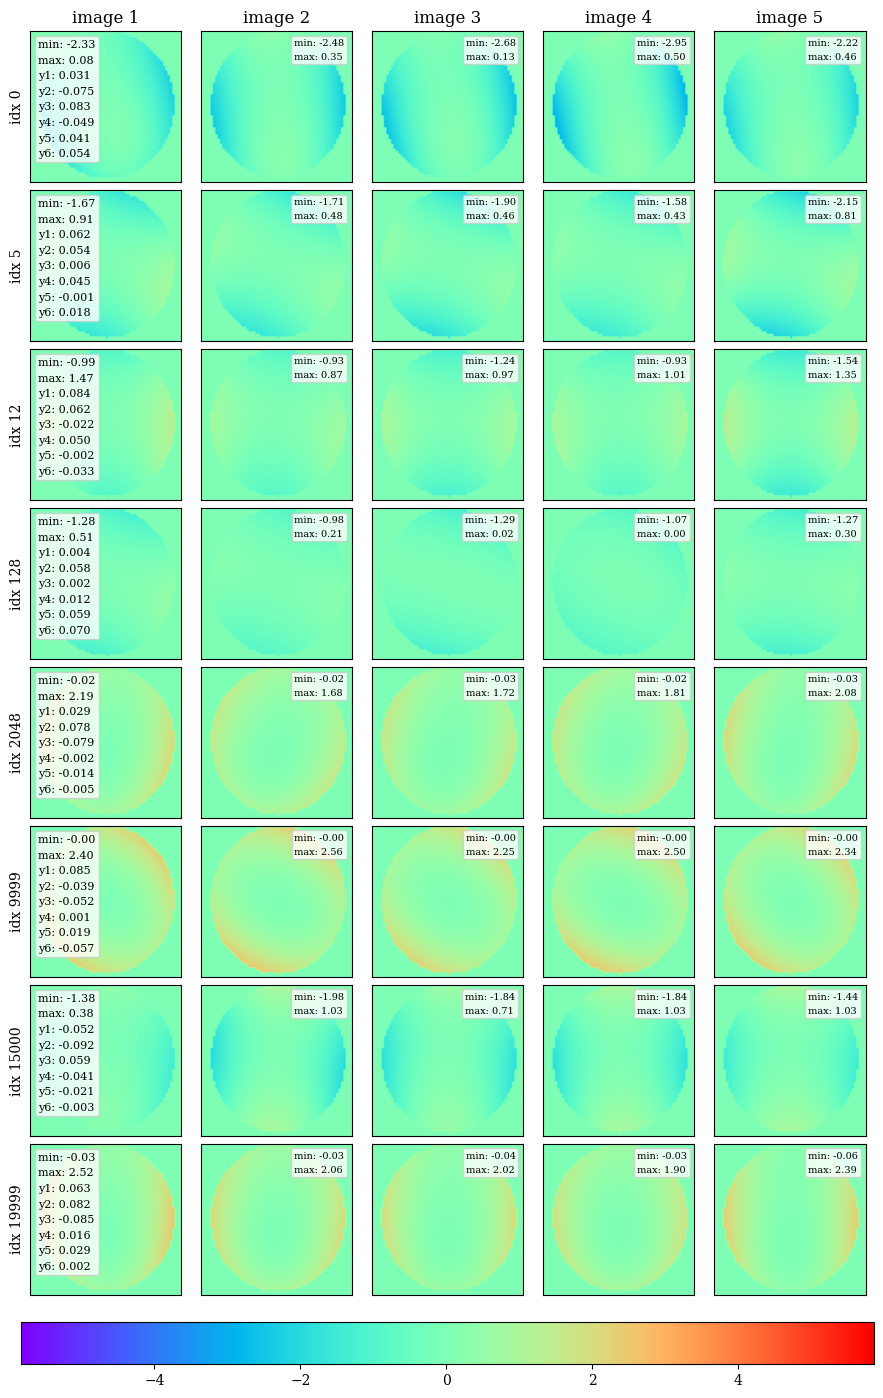

In [14]:
selected_index_list = [0, 5, 12, 128, 2048, 9999, 15000, 19999]
plot_trainingsample(X, y, selected_index_list)

## PyTorching the Model 

In [15]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
import pytorch_lightning as pl
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from torchvision import transforms
from torchvision.datasets import CIFAR10

In [16]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [17]:
# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [18]:
!nvidia-smi -L

GPU 0: NVIDIA GeForce RTX 3090 (UUID: GPU-81ef84f4-69df-ce9c-b89c-0b05c8f72ebf)


In [19]:
#%load_ext tensorboard
# I will not use tensorboard .. though..

In [20]:
# Setting the seed
pl.seed_everything(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Seed set to 42


#### Checkpoints 

In [21]:
CHECKPOINT_ROOT = '/app/kdrift/decenter+-0.095,tilt+-0.075/pytorch/checkpoints/'

In [22]:
from time import gmtime, strftime

base_name = 'cnn'
#try_name = strftime('%Y.%m.%d_%H:%M', gmtime())
try_name = 'take7'
experiment_name = f"{base_name}_{try_name}"
print("experiment:", experiment_name)
CHECKPOINT_PATH = os.path.join(CHECKPOINT_ROOT, experiment_name)

experiment: cnn_take7


In [23]:
import os
import shutil

CHECKPOINT_PATH = os.path.join(CHECKPOINT_ROOT, experiment_name)

if os.path.exists(CHECKPOINT_PATH):
    print(f"⚠️ Directory exists: {CHECKPOINT_PATH}")
    print("🧹 Removing all contents...")

    # Clear all files/subfolders inside the directory
    for filename in os.listdir(CHECKPOINT_PATH):
        file_path = os.path.join(CHECKPOINT_PATH, filename)
        try:
            if os.path.isfile(file_path) or os.path.islink(file_path):
                os.unlink(file_path)
            elif os.path.isdir(file_path):
                shutil.rmtree(file_path)
        except Exception as e:
            print(f"❌ Failed to delete {file_path}: {e}")

    print("✅ Directory has been cleared.")
else:
    os.makedirs(CHECKPOINT_PATH)
    print(f"✅ Directory created: {CHECKPOINT_PATH}")

print(f"📂 Experiment directory is ready: {os.path.abspath(CHECKPOINT_PATH)}")

✅ Directory created: /app/kdrift/decenter+-0.095,tilt+-0.075/pytorch/checkpoints/cnn_take7
📂 Experiment directory is ready: /app/kdrift/decenter+-0.095,tilt+-0.075/pytorch/checkpoints/cnn_take7


### Follow the min/max/scaler of the original keras code for reproduction

In [24]:
num_samples = len(y)
print(num_samples)

20000


In [25]:
indices=range(num_samples)

In [26]:
X_train, X_test, y_train, y_test, train_indices, test_indices = \
train_test_split(X, y, indices, test_size=0.2, random_state=42)

In [27]:
%%time
X_train_train, X_train_val, \
y_train_train, y_train_val, \
train_train_indices, train_val_indices = \
    train_test_split(
        X_train,
        y_train,
        train_indices,
        test_size=0.2,
        random_state=42
    )

CPU times: user 76.4 ms, sys: 60.1 ms, total: 137 ms
Wall time: 136 ms


In [28]:
np_array_info(X_train_train)

shape     : (12800, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 262144000
itemsize  : 4 bytes
nbytes    : 1000.00 MB
min / max : -5.8238911628723145 / 5.863417148590088


In [29]:
np_array_info(X_train_val)

shape     : (3200, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 65536000
itemsize  : 4 bytes
nbytes    : 250.00 MB
min / max : -5.519207954406738 / 5.788288116455078


In [30]:
np_array_info(X_test)

shape     : (4000, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 81920000
itemsize  : 4 bytes
nbytes    : 312.50 MB
min / max : -5.644690990447998 / 5.729836940765381


### normalization by a fixed max value

#### Max Min Histograms 

In [34]:
# X shape: (N, C, H, W, 1)
# squeeze 마지막 채널
X0 = X_train_train[..., 0]   # (12800, 5, 64, 64)

# 채널별 min / max (per-sample)
# 결과 shape: (12800, 5)
max_vals = X0.max(axis=(2, 3))
min_vals = X0.min(axis=(2, 3))

print(max_vals.shape, min_vals.shape)

(12800, 5) (12800, 5)


In [35]:
# 채널별 max of max_vals
max_of_max = max_vals.max(axis=0)   # shape (5,)

# 채널별 min of min_vals
min_of_min = min_vals.min(axis=0)   # shape (5,)

print("Channel-wise MAX of max_vals:")
for c, v in enumerate(max_of_max):
    print(f"  Channel {c}: {v:.6f}")

print("\nChannel-wise MIN of min_vals:")
for c, v in enumerate(min_of_min):
    print(f"  Channel {c}: {v:.6f}")

Channel-wise MAX of max_vals:
  Channel 0: 5.274002
  Channel 1: 5.744557
  Channel 2: 5.334452
  Channel 3: 5.859862
  Channel 4: 5.863417

Channel-wise MIN of min_vals:
  Channel 0: -5.221497
  Channel 1: -5.499168
  Channel 2: -5.580663
  Channel 3: -5.210266
  Channel 4: -5.823891


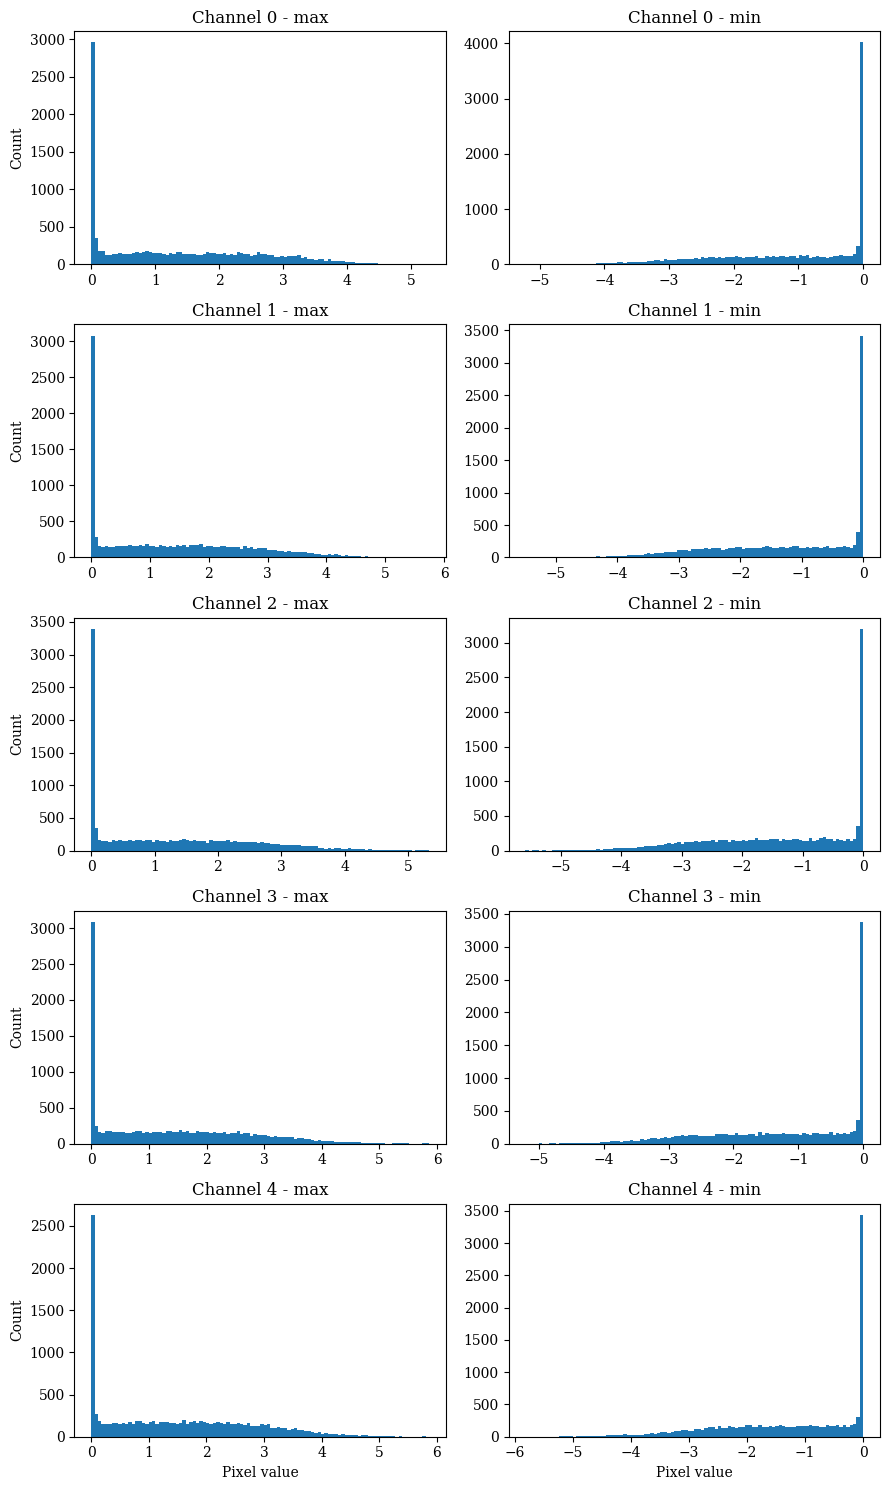

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 2, figsize=(9, 15), sharex=False)

for c in range(5):
    # max histogram
    axes[c, 0].hist(max_vals[:, c], bins=100)
    axes[c, 0].set_title(f'Channel {c} - max')
    axes[c, 0].set_ylabel('Count')

    # min histogram
    axes[c, 1].hist(min_vals[:, c], bins=100)
    axes[c, 1].set_title(f'Channel {c} - min')

axes[-1, 0].set_xlabel('Pixel value')
axes[-1, 1].set_xlabel('Pixel value')

plt.tight_layout()
plt.show()

In [38]:
for i in range(y_train_train.shape[1]):
    print(f"channel {i}: min={y[:, i].min()}, max={y[:, i].max()}")

channel 0: min=-0.0949999988079071, max=0.09499000012874603
channel 1: min=-0.0949999988079071, max=0.09498000144958496
channel 2: min=-0.0949999988079071, max=0.09499000012874603
channel 3: min=-0.07500000298023224, max=0.07498999685049057
channel 4: min=-0.07500000298023224, max=0.07500000298023224
channel 5: min=-0.07498999685049057, max=0.07498999685049057


In [39]:
for i in range(y_train_val.shape[1]):
    print(f"channel {i}: min={y[:, i].min()}, max={y[:, i].max()}")

channel 0: min=-0.0949999988079071, max=0.09499000012874603
channel 1: min=-0.0949999988079071, max=0.09498000144958496
channel 2: min=-0.0949999988079071, max=0.09499000012874603
channel 3: min=-0.07500000298023224, max=0.07498999685049057
channel 4: min=-0.07500000298023224, max=0.07500000298023224
channel 5: min=-0.07498999685049057, max=0.07498999685049057


In [40]:
for i in range(y_test.shape[1]):
    print(f"channel {i}: min={y[:, i].min()}, max={y[:, i].max()}")

channel 0: min=-0.0949999988079071, max=0.09499000012874603
channel 1: min=-0.0949999988079071, max=0.09498000144958496
channel 2: min=-0.0949999988079071, max=0.09499000012874603
channel 3: min=-0.07500000298023224, max=0.07498999685049057
channel 4: min=-0.07500000298023224, max=0.07500000298023224
channel 5: min=-0.07498999685049057, max=0.07498999685049057


#### Rescaling the input

In [41]:
MAX_CAP = 6.0
MAX_RANGE = 12.0

In [50]:
YL_CAP = 0.095
YH_CAP = 0.075

In [43]:
%%time
import numpy as np

# symmetric rescaling per image
X_train_train_scaled = (X_train_train + MAX_CAP)/MAX_RANGE

CPU times: user 89.4 ms, sys: 1.99 s, total: 2.08 s
Wall time: 2.16 s


In [44]:
# symmetric rescaling per image
X_train_val_scaled = (X_train_val + MAX_CAP)/MAX_RANGE

In [45]:
# symmetric rescaling per image
X_test_scaled = (X_test + MAX_CAP)/MAX_RANGE

In [60]:
np_array_info(X_train_train_scaled)

shape     : (12800, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 262144000
itemsize  : 4 bytes
nbytes    : 1000.00 MB
min / max : 0.014675736427307129 / 0.9886180758476257


In [58]:
np_array_info(X_train_val_scaled)

shape     : (3200, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 65536000
itemsize  : 4 bytes
nbytes    : 250.00 MB
min / max : 0.04006600379943848 / 0.9823573231697083


In [59]:
np_array_info(X_test_scaled)

shape     : (4000, 5, 64, 64, 1)
dtype     : float32
ndim      : 5
size      : 81920000
itemsize  : 4 bytes
nbytes    : 312.50 MB
min / max : 0.029609084129333496 / 0.9774864315986633


In [48]:
y_train_train_scaled = np.zeros_like(y_train_train)
y_train_val_scaled = np.zeros_like(y_train_val)
y_test_scaled = np.zeros_like(y_test)

# 채널 0~2
for i in range(3):
    y_train_train_scaled[:, i] = y_train_train[:, i]/YL_CAP
    y_train_val_scaled[:, i] = y_train_val[:, i]/YL_CAP
    y_test_scaled[:, i] = y_test[:, i]/YL_CAP

# 채널 3~5
for i in range(3, 6):
    y_train_train_scaled[:, i] = y_train_train[:, i]/YH_CAP
    y_train_val_scaled[:, i] = y_train_val[:, i]/YH_CAP
    y_test_scaled[:, i] = y_test[:, i]/YH_CAP

In [51]:
for i in range(y_train_train_scaled.shape[1]):
    print(f"channel {i}: min={y_train_train_scaled[:, i].min()}, \
    max={y_train_train_scaled[:, i].max()}")

channel 0: min=-1.0,     max=0.9998947381973267
channel 1: min=-0.9996842741966248,     max=0.9996842741966248
channel 2: min=-1.0,     max=0.9998947381973267
channel 3: min=-1.0,     max=0.9998666048049927
channel 4: min=-0.9995999336242676,     max=1.0
channel 5: min=-0.9998666048049927,     max=0.9998666048049927


In [52]:
for i in range(y_train_val_scaled.shape[1]):
    print(f"channel {i}: min={y_train_val_scaled[:, i].min()}, \
    max={y_train_val_scaled[:, i].max()}")

channel 0: min=-0.9996842741966248,     max=0.9981052875518799
channel 1: min=-0.9997894763946533,     max=0.9997894763946533
channel 2: min=-0.9988421201705933,     max=0.9996842741966248
channel 3: min=-0.9998666048049927,     max=0.9990665912628174
channel 4: min=-1.0,     max=0.9997332692146301
channel 5: min=-0.9997332692146301,     max=0.9982665777206421


In [53]:
for i in range(y_test_scaled.shape[1]):
    print(f"channel {i}: min={y_test_scaled[:, i].min()}, \
    max={y_test_scaled[:, i].max()}")

channel 0: min=-0.9995789527893066,     max=0.9996842741966248
channel 1: min=-1.0,     max=0.9996842741966248
channel 2: min=-0.9996842741966248,     max=0.9998947381973267
channel 3: min=-0.9997332692146301,     max=0.9995999336242676
channel 4: min=-0.9994666576385498,     max=0.9997332692146301
channel 5: min=-0.9998666048049927,     max=0.9998666048049927


> Indeed, we do not have to rescale `y_test` though... 

#### Plot the rescaled Training Sample 

- this could be wrong?!?

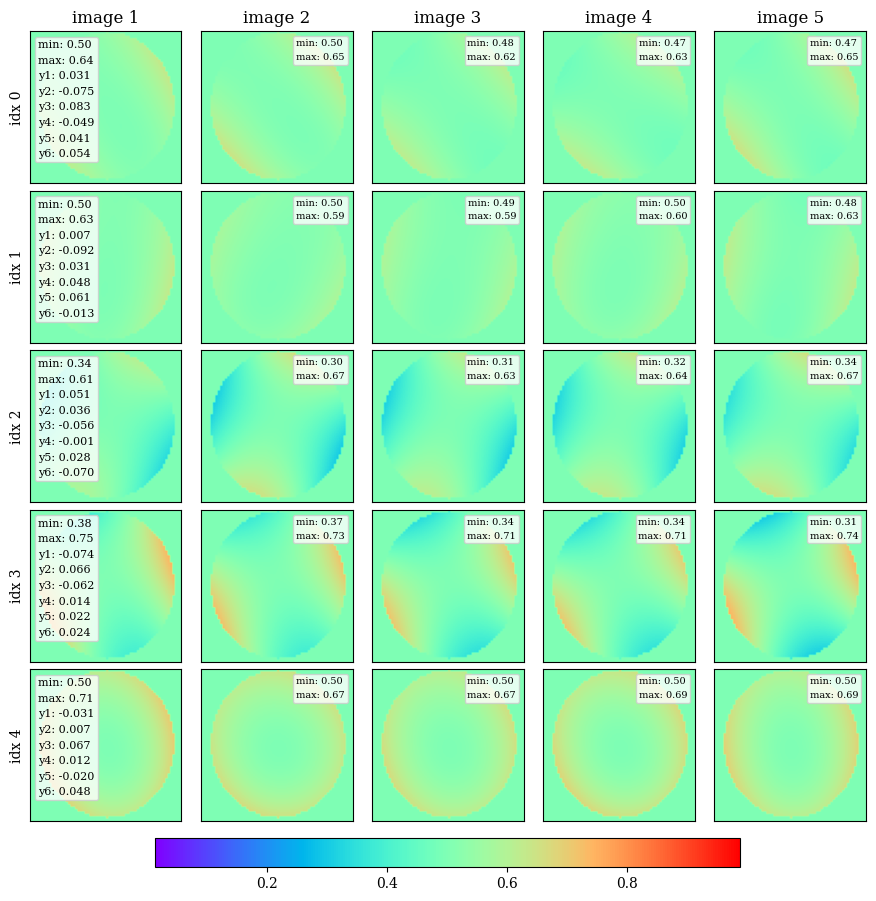

In [61]:
plot_trainingsample(X_train_train_scaled, y,[0,1,2,3,4])

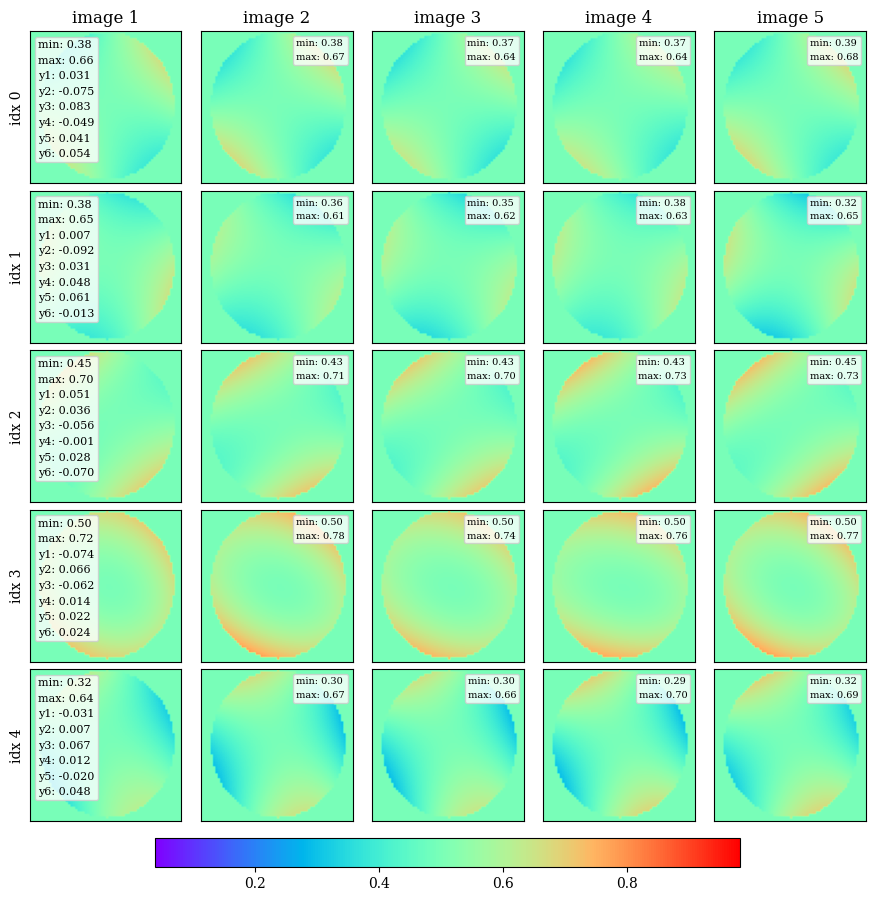

In [62]:
plot_trainingsample(X_train_val_scaled, y,[0,1,2,3,4])

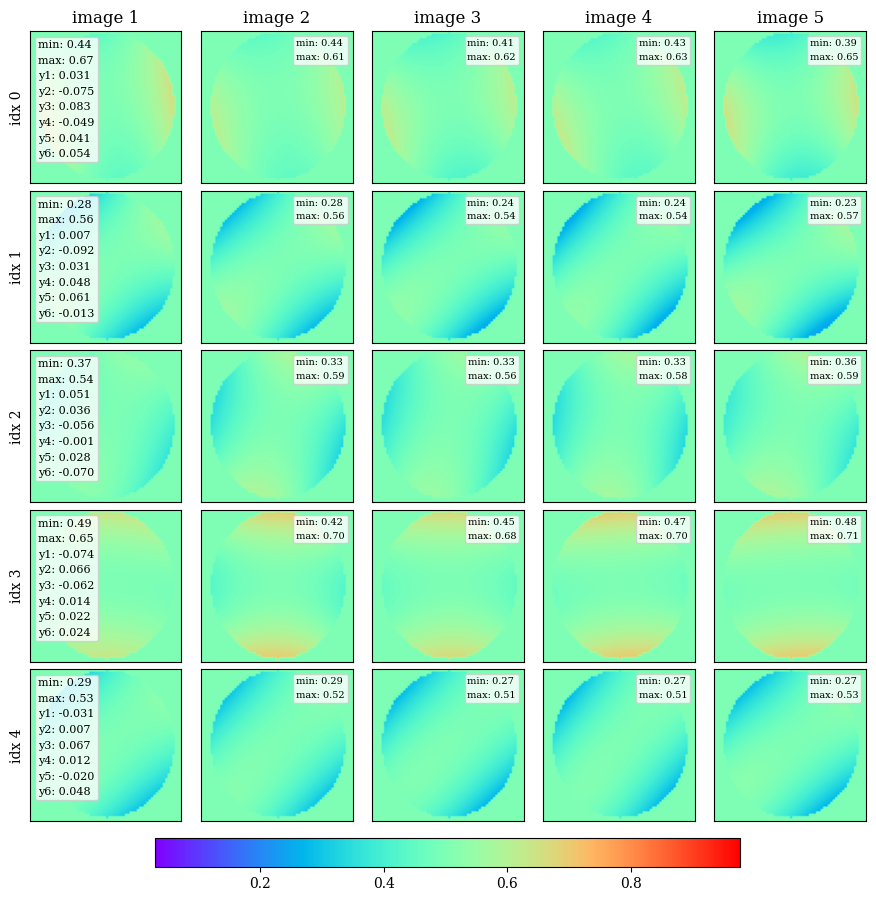

In [63]:
plot_trainingsample(X_test_scaled, y,[0,1,2,3,4])

In [64]:
import matplotlib.pyplot as plt
import numpy as np

def plot_y_histograms_splits(y_train_train, y_train_val, y_test, bins=50):
    """
    y_* shape: (N, 6)
    """

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    axes = axes.ravel()

    # symmetric range across ALL splits
    all_y = np.concatenate([y_train_train, y_train_val, y_test], axis=0)
    vmin = all_y.min()
    vmax = all_y.max()
    vmax = max(abs(vmin), abs(vmax))
    hist_range = (-vmax, vmax)

    for i in range(6):
        ax = axes[i]

        ax.hist(
            y_train_train[:, i],
            bins=bins,
            range=hist_range,
            density=True,
            color='r',
            alpha=0.2,
            label="train"
        )
        ax.hist(
            y_train_val[:, i],
            bins=bins,
            range=hist_range,
            density=True,
            color='g',
            alpha=0.2,
            label="val"
        )
        ax.hist(
            y_test[:, i],
            bins=bins,
            range=hist_range,
            density=True,
            color='b',
            alpha=0.2,
            label="test"
        )

        ax.axvline(0, color="k", linestyle="--", linewidth=1)
        ax.set_title(f"y{i}")
        ax.set_xlabel("value")
        ax.set_ylabel("density")

        if i == 0:
            ax.legend()

    fig.suptitle("Distribution of y components (train / val / test)", fontsize=13)
    fig.tight_layout()
    plt.show()

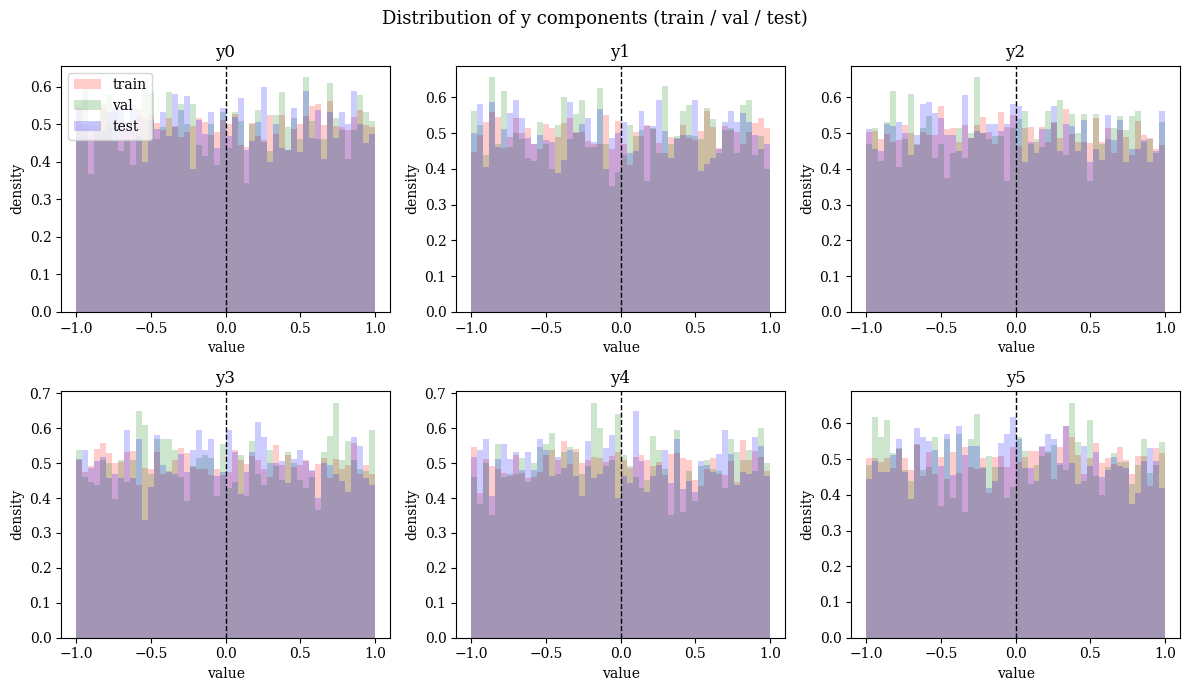

In [65]:
plot_y_histograms_splits(y_train_train_scaled, y_train_val_scaled, y_test_scaled)

## Train the CNN model

In [66]:
class CNNModelKerasEquivalent(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Conv2D(32,(1,1), relu, input_shape=(5,64,64), channels_first)
            nn.Conv2d(in_channels=5, out_channels=32, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv2D(64,(3,3), relu)  (padding='valid' in Keras -> padding=0 in PyTorch)
            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Conv2D(32,(2,2), relu)
            nn.Conv2d(64, 32, kernel_size=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Conv2D(32,(1,1), relu)
            nn.Conv2d(32, 32, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Conv2D(32,(1,1), relu)
            nn.Conv2d(32, 32, kernel_size=1),
            nn.ReLU(inplace=True),

            nn.Flatten(),                 # Keras Flatten()
            nn.Linear(32 * 3 * 3, 128),   # 계산 결과: 64->32->30->15->14->7->3 => 32*3*3
            nn.ReLU(inplace=True),
            nn.Linear(128, 6)             # Dense(6)
        )

    def forward(self, x):
        return self.net(x)

In [67]:
from torch.utils.data import Dataset, DataLoader

class NumpyDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx]).float()  # (5,64,64)
        x = x.squeeze(-1) # if (5,64,64,1)
        t = torch.from_numpy(self.y[idx]).float()  # (6,)
        return x, t

In [83]:
train_ds = NumpyDataset(X_train_train_scaled, y_train_train_scaled)
val_ds   = NumpyDataset(X_train_val_scaled,   y_train_val_scaled)

In [84]:
x0, y0 = train_ds[0]
print(x0.shape)   # torch.Size([5, 64, 64])
print(y0.shape)   # torch.Size([6])

torch.Size([5, 64, 64])
torch.Size([6])


In [85]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

In [86]:
xb, yb = next(iter(train_loader))
print("xb.shape:", xb.shape)
print("yb.shape:", yb.shape)
print("xb.dtype:", xb.dtype)

xb.shape: torch.Size([32, 5, 64, 64])
yb.shape: torch.Size([32, 6])
xb.dtype: torch.float32


#### Visualize the training dataloader as a sanity check

In [87]:
import numpy as np
import matplotlib.pyplot as plt

def plot_batch_patch_grid(xb, n_samples=8, ngrid=16, cmap="rainbow",
                                   linewidth=0.5, vmin=None, vmax=None):
    """
    xb: torch.Tensor, shape (B, 5, 64, 64)
    n_samples: number of rows (samples)
    ngrid: number of grid cells per axis (e.g., 16 => patch size 4 for 64x64)
    """
    # tensor -> numpy
    x = xb[:n_samples].detach().cpu().numpy()  # (n_samples, 5, 64, 64)
    n_samples = x.shape[0]
    n_views = x.shape[1]
    H, W = x.shape[2], x.shape[3]

    assert H % ngrid == 0 and W % ngrid == 0, f"H,W must be divisible by ngrid. got {H},{W}, ngrid={ngrid}"
    patch_h = H // ngrid
    patch_w = W // ngrid

    # global color scale (consistent across all panels)
    if vmin is None:
        vmin = float(x.min())
    if vmax is None:
        vmax = float(x.max())

    fig, axes = plt.subplots(
        n_samples, n_views,
        figsize=(n_views * 2.2, n_samples * 2.2),
        constrained_layout=False
    )

    # in case n_samples == 1
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    im = None
    for i in range(n_samples):
        for j in range(n_views):
            ax = axes[i, j]
            img = x[i, j]  # (64,64)

            im = ax.imshow(
                img,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                aspect="equal",
                interpolation="nearest"
            )

            ax.set_xticks([])
            ax.set_yticks([])

            # column titles
            if i == 0:
                ax.set_title(f"ch {j}", fontsize=11)

            # row labels
            if j == 0:
                ax.set_ylabel(f"sample {i}", fontsize=11)

            # draw patch grid boundaries
            for gy in range(0, H + 1, patch_h):
                ax.axhline(gy - 0.5, color="w", linewidth=linewidth, alpha=0.9)
            for gx in range(0, W + 1, patch_w):
                ax.axvline(gx - 0.5, color="w", linewidth=linewidth, alpha=0.9)

    # tighter spacing + bottom colorbar
    fig.subplots_adjust(bottom=0.08, hspace=0.02, wspace=0.02)

    cbar = fig.colorbar(
        im,
        ax=axes,
        orientation="horizontal",
        fraction=0.035,
        pad=0.02
    )
    cbar.set_label("pixel value")

    plt.show()

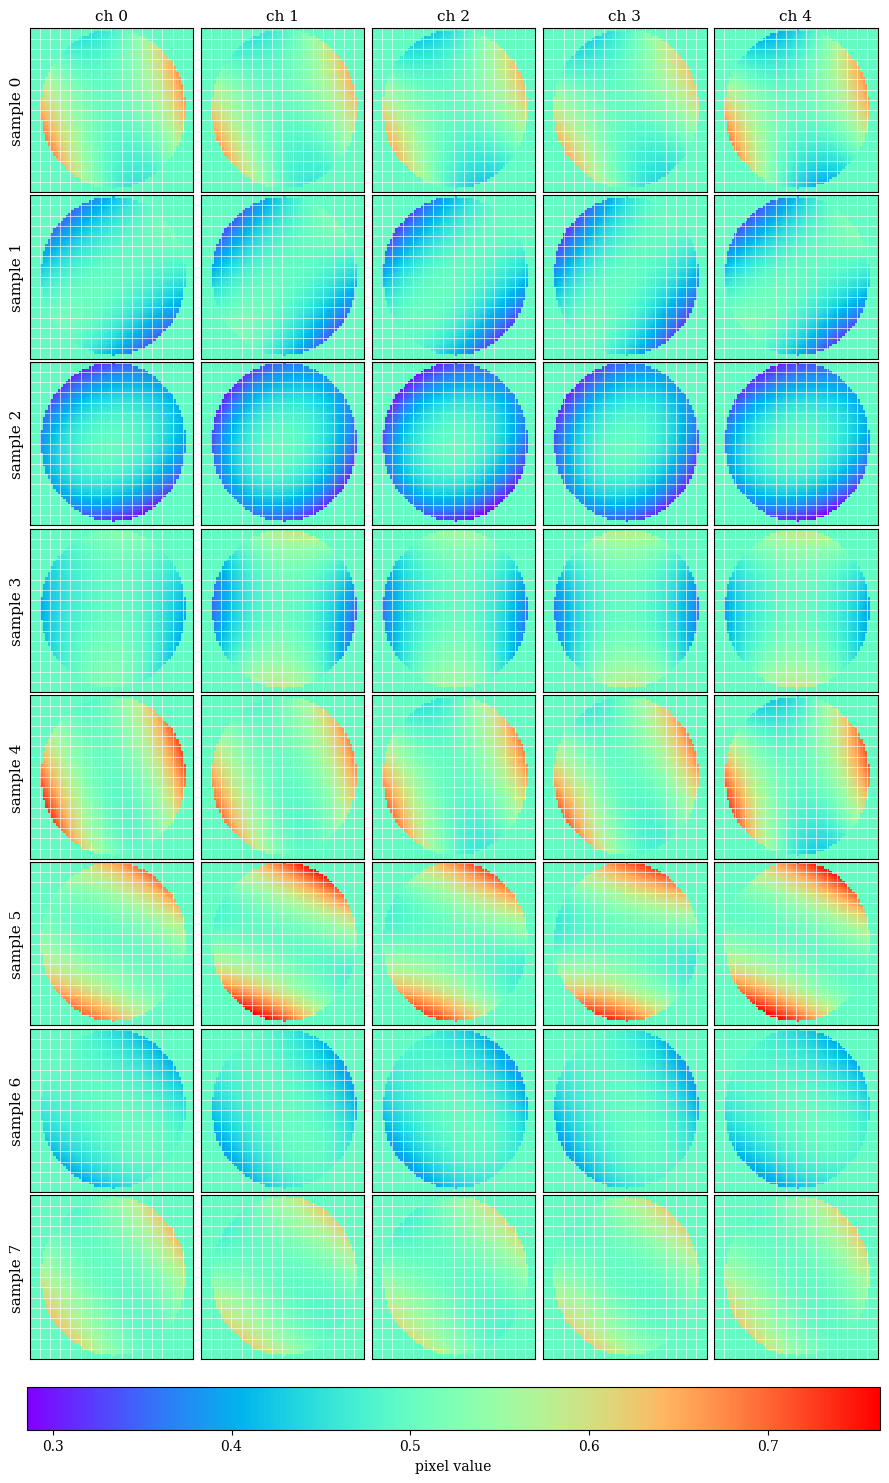

In [88]:
plot_batch_patch_grid(xb, n_samples=8, ngrid=16, cmap="rainbow")

In [89]:
xb, yb = next(iter(val_loader))
print("xb.shape:", xb.shape)
print("yb.shape:", yb.shape)
print("xb.dtype:", xb.dtype)

xb.shape: torch.Size([32, 5, 64, 64])
yb.shape: torch.Size([32, 6])
xb.dtype: torch.float32


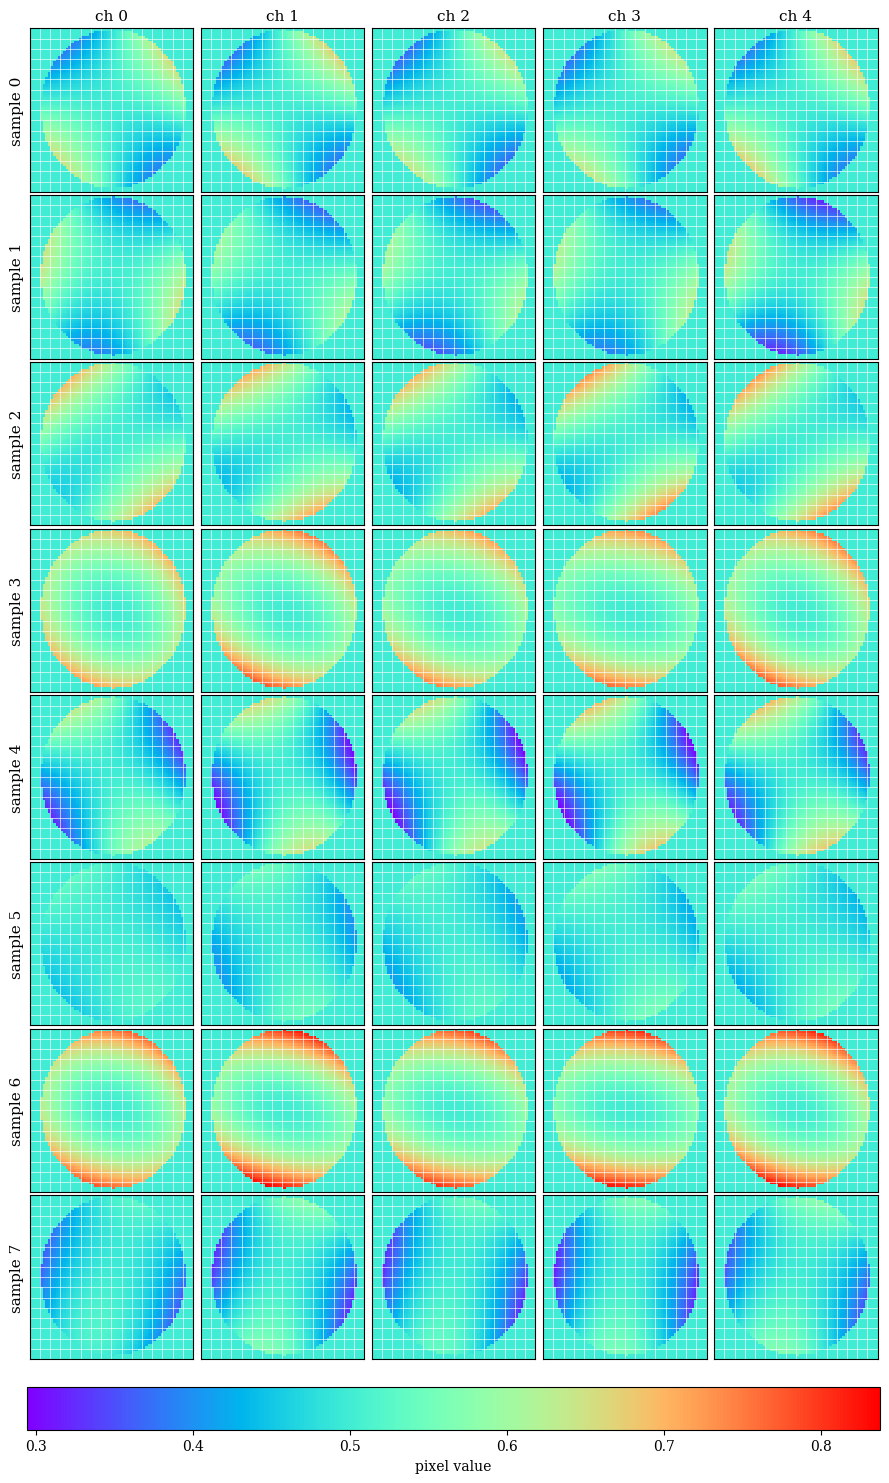

In [90]:
plot_batch_patch_grid(xb, n_samples=8, ngrid=16, cmap="rainbow")

#### Callbacks 

In [91]:
import time
import matplotlib.pyplot as plt
from pytorch_lightning.callbacks import Callback

class PlotLossesPL(Callback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.epoch_times = []

    def on_train_epoch_start(self, trainer, pl_module):
        self.epoch_start_time = time.time()

    def on_train_epoch_end(self, trainer, pl_module):
        epoch_time = time.time() - self.epoch_start_time
        self.epoch_times.append(epoch_time)

        train_loss = trainer.callback_metrics.get("train_loss")
        val_loss   = trainer.callback_metrics.get("val_loss")

        if train_loss is not None:
            self.train_losses.append(train_loss.item())
        if val_loss is not None:
            self.val_losses.append(val_loss.item())

        print(
            f"Epoch {trainer.current_epoch:03d} | "
            f"train MAE: {self.train_losses[-1]:.6f} | "
            f"val MAE: {self.val_losses[-1]:.6f} | "
            f"time: {epoch_time:.2f}s"
        )

    def on_fit_end(self, trainer, pl_module):
        self.plot()

    def plot(self):
        plt.figure(figsize=(6,4))
        plt.plot(self.train_losses, label="train")
        plt.plot(self.val_losses, label="val")
        plt.xlabel("epoch")
        plt.ylabel("MAE")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [92]:
import time
from pytorch_lightning.callbacks import Callback

class GPUSleepCallback(Callback):
    def __init__(self, every_n_epochs=5, sleep_seconds=5):
        self.every_n_epochs = every_n_epochs
        self.sleep_seconds = sleep_seconds

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1  # 1-based로 보기 좋게
        if epoch % self.every_n_epochs == 0:
            print(f"😴 Cooling GPU: sleeping {self.sleep_seconds}s after epoch {epoch}")
            time.sleep(self.sleep_seconds)

In [105]:
import os
from pytorch_lightning.callbacks import ModelCheckpoint

#ckpt_dir = "/app/kdrift/decenter_+-0.5mm,tilt_+-0.6deg/pytorch/checkpoints/cnn_take1"
ckpt_dir = CHECKPOINT_PATH

checkpoint_cb = ModelCheckpoint(
    dirpath=ckpt_dir,
    filename="best-{epoch:03d}-{val_loss:.6f}",  # 파일명 템플릿
    monitor="val_loss",                          # 우리가 log한 키
    mode="min",                                  # 최소가 best
    save_top_k=10,                                # best 1개만 유지
    save_last=True,                              # last.ckpt도 저장
    auto_insert_metric_name=False
)

In [94]:
import pytorch_lightning as pl
import torch
import torch.nn as nn

class LitCNN(pl.LightningModule):
    def __init__(self, model, lr=1e-3):
        super().__init__()
        self.model = model
        self.criterion = nn.L1Loss()
        self.lr = lr

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log("train_loss", loss, prog_bar=False)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log("val_loss", loss, prog_bar=False)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

In [95]:
from pytorch_lightning.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=100,
    mode="min"
)

In [96]:
from pytorch_lightning import Trainer

plot_cb = PlotLossesPL()
gpu_sleep_cb = GPUSleepCallback(every_n_epochs=5, sleep_seconds=5)

trainer = Trainer(
    max_epochs=400,
    callbacks=[plot_cb, checkpoint_cb, gpu_sleep_cb],
    enable_progress_bar=False,
    enable_model_summary=False,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    log_every_n_steps=999999
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


/usr/local/lib/python3.10/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /app/kdrift/decenter+-0.095,tilt+-0.075/pytorch/checkpoints/cnn_take7 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 000 | train MAE: 0.318905 | val MAE: 0.323966 | time: 1.49s
Epoch 001 | train MAE: 0.319358 | val MAE: 0.317804 | time: 1.60s
Epoch 002 | train MAE: 0.308633 | val MAE: 0.318399 | time: 1.61s
Epoch 003 | train MAE: 0.328985 | val MAE: 0.314948 | time: 1.62s
Epoch 004 | train MAE: 0.331356 | val MAE: 0.311178 | time: 1.63s
😴 Cooling GPU: sleeping 5s after epoch 5
Epoch 005 | train MAE: 0.177774 | val MAE: 0.183114 | time: 1.61s
Epoch 006 | train MAE: 0.173353 | val MAE: 0.150847 | time: 1.60s
Epoch 007 | train MAE: 0.124490 | val MAE: 0.142317 | time: 1.65s
Epoch 008 | train MAE: 0.124455 | val MAE: 0.136756 | time: 1.60s
Epoch 009 | train MAE: 0.145238 | val MAE: 0.138200 | time: 1.57s
😴 Cooling GPU: sleeping 5s after epoch 10
Epoch 010 | train MAE: 0.123977 | val MAE: 0.132206 | time: 1.66s
Epoch 011 | train MAE: 0.113831 | val MAE: 0.143975 | time: 1.63s
Epoch 012 | train MAE: 0.133313 | val MAE: 0.136142 | time: 1.61s
Epoch 013 | train MAE: 0.126704 | val MAE: 0.127625 | time:

`Trainer.fit` stopped: `max_epochs=400` reached.


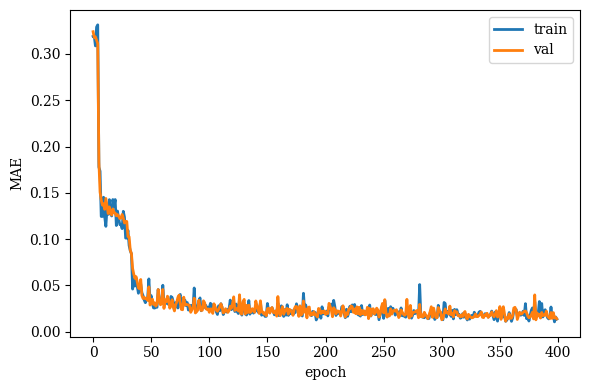

CPU times: user 10min 29s, sys: 3min 33s, total: 14min 3s
Wall time: 17min 36s


In [97]:
%%time
trainer.fit(
    model=LitCNN(CNNModelKerasEquivalent()),
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)

#### Save the training history

In [98]:
CHECKPOINT_PATH

'/app/kdrift/decenter+-0.095,tilt+-0.075/pytorch/checkpoints/cnn_take7'

In [100]:
train_losses = np.array(plot_cb.train_losses, dtype=np.float32)
val_losses   = np.array(plot_cb.val_losses,   dtype=np.float32)
epochs = np.arange(1, len(train_losses) + 1, dtype=np.int32)

In [102]:
df = pd.DataFrame({
    "epoch": epochs,
    "train_losses": train_losses,
    "val_losses": val_losses,
})

df.to_csv(f"{CHECKPOINT_PATH}/training_history.csv", index=False)

In [103]:
%ls {CHECKPOINT_PATH}

best-005-0.012125.ckpt  last-v1.ckpt  training_history.csv
best-355-0.011451.ckpt  last.ckpt


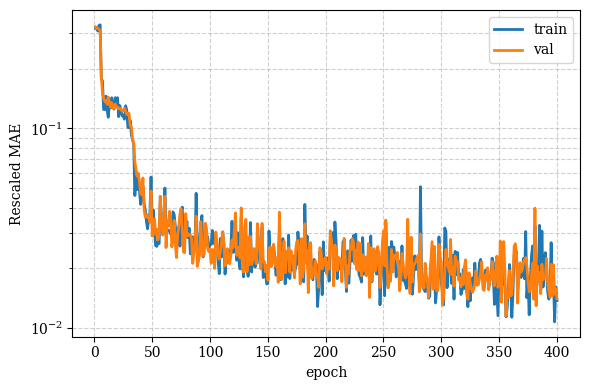

In [104]:
plt.figure(figsize=(6, 4))

plt.plot(epochs, train_losses, label="train")
plt.plot(epochs, val_losses, label="val")

plt.xlabel("epoch")
plt.ylabel("Rescaled MAE")

plt.yscale("log")          # 👈 y축 로그 스케일
plt.grid(True, which="both", linestyle="--", alpha=0.6)  # 👈 grid

plt.legend()
plt.tight_layout()
plt.show()

## Evaluation 

In [106]:
test_ds = NumpyDataset(X_test_scaled, y_test_scaled)
test_loader   = DataLoader(test_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

In [107]:
x0, y0 = test_ds[0]
print(x0.shape)   # torch.Size([5, 64, 64])
print(y0.shape)   # torch.Size([6])

torch.Size([5, 64, 64])
torch.Size([6])


In [108]:
def get_test_predictions(model, test_loader, device):
    model.eval()

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            y_hat = model(xb)          # (B, 6)

            y_true_list.append(yb.cpu().numpy())
            y_pred_list.append(y_hat.cpu().numpy())

    y_true = np.concatenate(y_true_list, axis=0)  # (N_test, 6)
    y_pred = np.concatenate(y_pred_list, axis=0)  # (N_test, 6)

    return y_true, y_pred

In [109]:
%ls {CHECKPOINT_PATH}

best-005-0.012125.ckpt  last-v1.ckpt  training_history.csv
best-355-0.011451.ckpt  last.ckpt


In [110]:
best_ckpt = f"{CHECKPOINT_PATH}/best-355-0.011451.ckpt"
lit_model = LitCNN.load_from_checkpoint(
    best_ckpt,
    model=CNNModelKerasEquivalent(),  # 🔴 구조 동일해야 함
)

In [111]:
%%time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
y_test_true, y_test_pred = get_test_predictions(lit_model, test_loader, device)

CPU times: user 149 ms, sys: 179 ms, total: 329 ms
Wall time: 284 ms


In [112]:
print(y_test_true.shape)  # (N_test, 6)
print(y_test_pred.shape)  # (N_test, 6)

(4000, 6)
(4000, 6)


In [114]:
y_test_true[0],y_test_pred[0]

(array([ 0.13189474,  0.22736843, -0.23357897,  0.9337332 , -0.06053333,
        -0.5965333 ], dtype=float32),
 array([ 0.14097145,  0.22232345, -0.23450857,  0.92399544, -0.06315588,
        -0.5919493 ], dtype=float32))

#### Scale back to the real scale for the final performance test

In [119]:
YL_CAP, YH_CAP

(0.095, 0.075)

In [120]:
scales = np.array([YL_CAP]*3 + [YH_CAP]*3)  # shape: (6,)

y_test_true_descaled = y_test_true * scales
y_test_pred_descaled = y_test_pred * scales

In [123]:
mae = np.mean(np.abs(y_test_pred - y_test_true), axis=0)
print("Test MAE per y:", mae)
print("Test MAE mean :", mae.mean())

Test MAE per y: [0.02446488 0.01237282 0.00426752 0.00668991 0.00790448 0.01130608]
Test MAE mean : 0.011167615


In [124]:
mae = np.mean(np.abs(y_test_pred_descaled - y_test_true_descaled), axis=0)
print("Test MAE per y:", mae)
print("Test MAE mean :", mae.mean())

Test MAE per y: [0.00232416 0.00117542 0.00040541 0.00050174 0.00059284 0.00084796]
Test MAE mean : 0.0009745883459869048


In [125]:
import matplotlib as mpl
import seaborn as sns

sns.reset_defaults()                 # seaborn 스타일 제거
mpl.rcParams.update(mpl.rcParamsDefault)  # matplotlib 완전 초기화

In [129]:
err = y_test_pred_descaled - y_test_true_descaled
print(err.shape)

(4000, 6)


In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",     # 🔹 whitegrid → white
    context="talk",
    font="serif"
)

In [133]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

def plot_error_histograms_seaborn(
    err,
    bins=40,
    xmin=-0.1,
    xmax=0.1,
    save_name="default.pdf",   # 👈 디폴트 파일명
):
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    axes = axes.ravel()

    xlim = (xmin, xmax)

    for i in range(6):
        ax = axes[i]

        sns.histplot(
            err[:, i],
            bins=bins,
            stat="count",
            kde=False,
            color="tab:blue",
            alpha=0.8,
            ax=ax
        )

        ax.axvline(0, color="black", linestyle="--", linewidth=1.5)

        mae  = np.mean(np.abs(err[:, i]))
        rmse = np.sqrt(np.mean(err[:, i] ** 2))

        ax.text(
            0.03, 0.97,
            f"MAE  = {mae:.4f}\nRMSE = {rmse:.4f}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=14,
            bbox=dict(boxstyle="round", fc="white", alpha=0.9)
        )

        ax.set_xlim(xlim)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

        ax.set_title(f"y{i} error", fontsize=16)
        ax.set_xlabel("prediction − truth", fontsize=14)
        ax.set_ylabel("count", fontsize=14)

    fig.suptitle(
        "Test error distribution : CNN MaxCap50 Postive Only Normalization Y Rescaled",
        fontsize=20,
        y=0.98
    )

    fig.tight_layout()

    # ✅ PDF 저장 (show 전에!)
    if save_name is not None:
        plt.savefig(save_name, bbox_inches="tight")
        print(f"Saved figure to: {save_name}")

    plt.show()

Saved figure to: cnn_maxcap50_positive_only_norm_y_rescaled.png


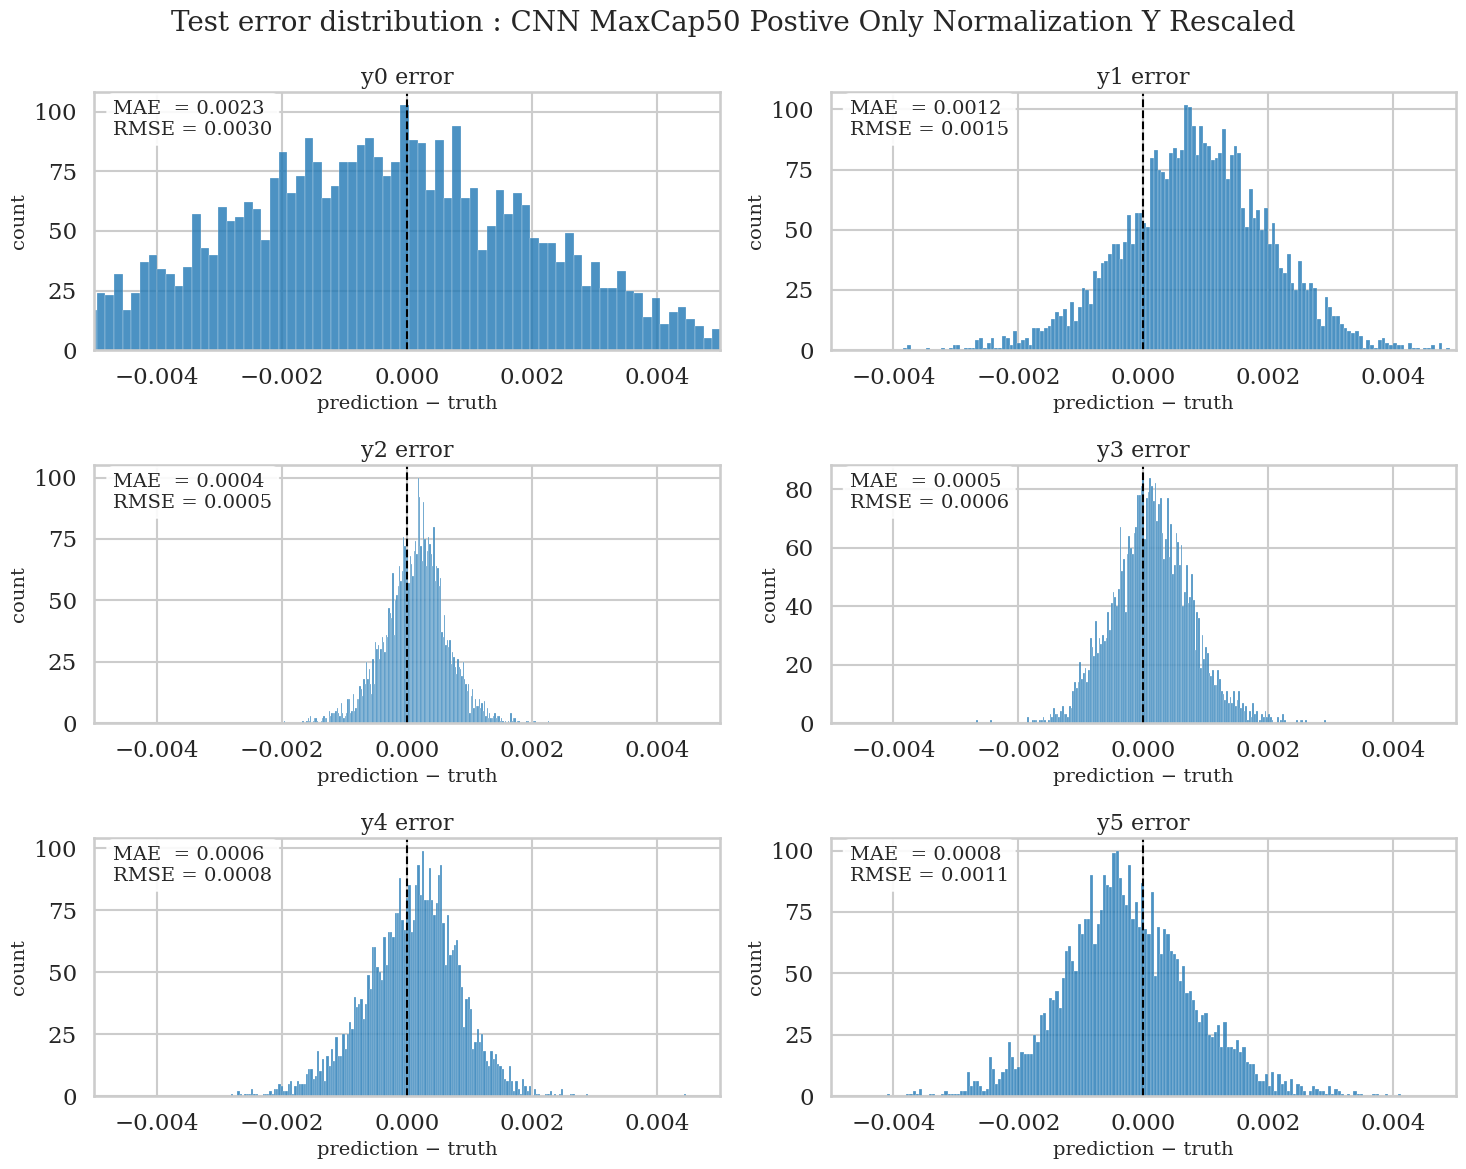

In [134]:
plot_error_histograms_seaborn(err,bins=200,xmin=-0.005,xmax=0.005, \
                             save_name='cnn_maxcap50_positive_only_norm_y_rescaled.png')